# 02: Multivariate Anomaly Detection — v2 (Improved Model)
## Objective
Build an improved anomaly detection model over v1 by introducing temporal feature engineering
and contamination parameter search, while retaining the same threshold-tuning approach.

### Key Improvements over v1
| Change | v1 | v2 |
|--------|-------|-------|
| Features | 4 raw sensors | 4 raw + 3 engineered (rolling std, rolling mean, cross-sensor ratio) |
| Contamination | Fixed 0.06 | Grid searched over [0.03, 0.05, 0.06, 0.08, 0.10] |
| n_estimators | 200 | 300 |
| Threshold | Tuned (F1 optimised) | Tuned (F1 optimised) |
| Saved model | isolation_forest_v1.joblib | isolation_forest_v2.joblib |

### Logic: Isolation Forest
Isolation Forest isolates anomalies by randomly partitioning the feature space. Anomalies
require fewer splits to isolate (shorter path length) and receive lower decision scores.

### Why Feature Engineering Helps
The v1 model was blind to *temporal volatility* — a sudden pH drop looks similar in raw
feature space to a gradual drift. Rolling standard deviation encodes rate-of-change,
making sharp events (Jan 4 crash) more isolable by the forest.

*Note: Preprocessing is kept minimal to preserve event fidelity.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay,
    matthews_corrcoef, roc_auc_score, average_precision_score
)

sns.set(style="whitegrid")
print("Imports complete.")

Imports complete.


In [2]:
# Load dataset (path assumes execution from /notebooks folder)
df = pd.read_csv("../data/smart_aquarium_dataset_v6.1.csv")

# Convert timestamp and sort to ensure temporal continuity
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

print(f"Dataset Loaded: {df.shape[0]} rows across {df.shape[1]} columns.")

Dataset Loaded: 8640 rows across 22 columns.


In [3]:
# Core sensors used for multivariate detection
feature_cols = ["temperature", "ph", "tds", "turbidity"]
label_col    = "is_anomaly"  # Ground truth for validation

# Isolate the modelling dataframe
df_model = df[feature_cols + [label_col]].copy()

In [4]:
# 1. Forward fill short telemetry gaps (packet loss)
df_model[feature_cols] = df_model[feature_cols].ffill()

# 2. Filter physically impossible values (hardware failures)
# Keep outliers that are physically possible but environmentally abnormal
df_model = df_model[
    (df_model["ph"].between(0, 14)) &
    (df_model["temperature"].between(0, 45)) &
    (df_model["tds"] >= 0) &
    (df_model["turbidity"] >= 0)
].copy()

print("Preprocessing Complete.")
print(f"Missing Values:\n{df_model[feature_cols].isnull().sum()}")

Preprocessing Complete.
Missing Values:
temperature    0
ph             0
tds            0
turbidity      0
dtype: int64


In [5]:
print("--- Ground Truth Anomaly Distribution ---")
print(df_model[label_col].value_counts())
print("\nPercentage View:")
print(df_model[label_col].value_counts(normalize=True) * 100)

--- Ground Truth Anomaly Distribution ---
is_anomaly
0    8376
1     264
Name: count, dtype: int64

Percentage View:
is_anomaly
0    96.944444
1     3.055556
Name: proportion, dtype: float64


---
## Feature Engineering
Three temporal and cross-sensor features are added to the raw sensor readings.
These capture *rate-of-change* and *cross-sensor relationships* that the raw values alone cannot express.

| Feature | Computation | Purpose |
|---------|------------|--------|
| `ph_rolling_std` | Rolling std of pH (window=5) | Captures sudden pH volatility / crashes |
| `turbidity_rolling_mean` | Rolling mean of turbidity (window=5) | Smooths spikes into sustained signal |
| `tds_ph_ratio` | TDS / (pH + 1e-6) | Cross-sensor interaction: high TDS + low pH = danger |

> **Why window=5?** At 10-minute intervals, a window of 5 covers 50 minutes — long enough
> to detect a sustained event, short enough to catch a rapid crash.

In [6]:
# --- Feature Engineering ---
WINDOW = 5

# 1. pH rolling standard deviation — captures sudden pH volatility
df_model["ph_rolling_std"] = df_model["ph"].rolling(window=WINDOW, min_periods=1).std().fillna(0)

# 2. Turbidity rolling mean — smooths spikes into a sustained signal
df_model["turbidity_rolling_mean"] = df_model["turbidity"].rolling(window=WINDOW, min_periods=1).mean()

# 3. TDS / pH ratio — cross-sensor interaction term
#    High TDS + low pH is a dangerous combination for aquatic life
df_model["tds_ph_ratio"] = df_model["tds"] / (df_model["ph"] + 1e-6)

# Updated feature set
feature_cols_v2 = feature_cols + ["ph_rolling_std", "turbidity_rolling_mean", "tds_ph_ratio"]

print(f"Features (v2): {feature_cols_v2}")
print(f"Feature matrix shape: {df_model[feature_cols_v2].shape}")

Features (v2): ['temperature', 'ph', 'tds', 'turbidity', 'ph_rolling_std', 'turbidity_rolling_mean', 'tds_ph_ratio']
Feature matrix shape: (8640, 7)


In [7]:
X      = df_model[feature_cols_v2].copy()
y_true = df_model[label_col].astype(int).copy()

print(f"Features ready: {feature_cols_v2}")

Features ready: ['temperature', 'ph', 'tds', 'turbidity', 'ph_rolling_std', 'turbidity_rolling_mean', 'tds_ph_ratio']


In [8]:
scaler_v2 = StandardScaler()
X_scaled  = scaler_v2.fit_transform(X)

print("Standardisation complete: Mean=0, Std=1")

Standardisation complete: Mean=0, Std=1


---
## Contamination Parameter Search
In v1, `contamination=0.06` was set manually. Here we search over a range of values
and select the one that maximises **ROC-AUC** — a threshold-independent metric that
measures the model's ability to rank anomalies above normal points.

ROC-AUC is used here (not F1) because it evaluates the full score distribution,
independent of any specific threshold choice.

In [9]:
# --- Contamination Parameter Search ---
contamination_values = [0.03, 0.05, 0.06, 0.08, 0.10]
search_results = []

for c in contamination_values:
    clf = IsolationForest(n_estimators=300, contamination=c, random_state=42)
    clf.fit(X_scaled)
    scores  = clf.decision_function(X_scaled)
    roc_auc = roc_auc_score(y_true, -scores)  # negate: lower score = more anomalous
    search_results.append({"contamination": c, "roc_auc": round(roc_auc, 4)})
    print(f"  contamination={c:.2f}  ROC-AUC={roc_auc:.4f}")

search_df       = pd.DataFrame(search_results).sort_values("roc_auc", ascending=False)
best_contamination = float(search_df.iloc[0]["contamination"])
print(f"\nBest contamination: {best_contamination}  (ROC-AUC={search_df.iloc[0]['roc_auc']})")

  contamination=0.03  ROC-AUC=0.6698
  contamination=0.05  ROC-AUC=0.6698
  contamination=0.06  ROC-AUC=0.6698
  contamination=0.08  ROC-AUC=0.6698
  contamination=0.10  ROC-AUC=0.6698

Best contamination: 0.03  (ROC-AUC=0.6698)


In [10]:
# --- Train final model with best contamination ---
iso_forest_v2 = IsolationForest(
    n_estimators=300,
    contamination=best_contamination,
    random_state=42
)
iso_forest_v2.fit(X_scaled)

# Binary predictions (default contamination cutoff)
y_pred_raw = iso_forest_v2.predict(X_scaled)
y_pred     = np.where(y_pred_raw == -1, 1, 0)
df_model["iforest_v2_pred"] = y_pred

print(f"Model v2 training complete.")
print(f"  n_estimators : 300")
print(f"  contamination: {best_contamination}")
print(f"  features     : {len(feature_cols_v2)}")
print(f"  flagged      : {y_pred.sum()} anomalies")

Model v2 training complete.
  n_estimators : 300
  contamination: 0.03
  features     : 7
  flagged      : 260 anomalies


--- v2 Model Baseline Evaluation Metrics ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8376
           1       0.21      0.21      0.21       264

    accuracy                           0.95      8640
   macro avg       0.59      0.59      0.59      8640
weighted avg       0.95      0.95      0.95      8640



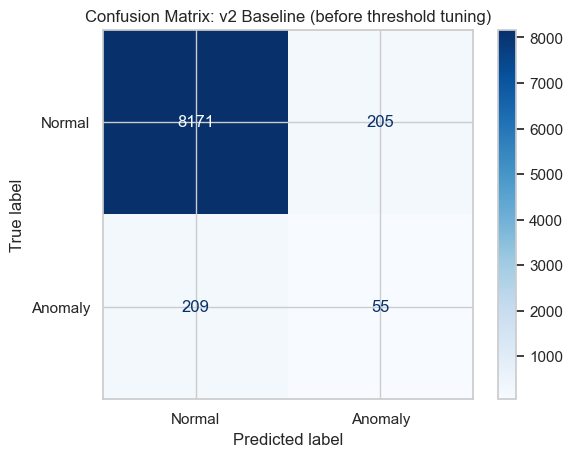

In [11]:
# --- Baseline evaluation (before threshold tuning) ---
print("--- v2 Model Baseline Evaluation Metrics ---")
print(classification_report(y_true, y_pred))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: v2 Baseline (before threshold tuning)")
plt.show()

---
## Threshold Tuning
Same approach as v1: evaluate multiple decision score thresholds and select the one
that maximises F1-score on the anomaly class.

With the improved feature set, the score distribution is expected to show better
separation between anomalies and normal points, making the threshold choice more impactful.

In [12]:
# --- Extract decision scores ---
df_model["iforest_v2_score"] = iso_forest_v2.decision_function(X_scaled)

# --- Evaluate multiple thresholds ---
thresholds = [-0.025, -0.01, 0.00, 0.01, 0.02, 0.03, 0.05, 0.08]
results = []

for t in thresholds:
    y_pred_t  = (df_model["iforest_v2_score"] < t).astype(int)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    recall    = recall_score(y_true, y_pred_t, zero_division=0)
    f1        = f1_score(y_true, y_pred_t, zero_division=0)
    flagged   = int(y_pred_t.sum())
    results.append({
        "threshold":     t,
        "precision":     round(precision, 3),
        "recall":        round(recall, 3),
        "f1_score":      round(f1, 3),
        "flagged_count": flagged
    })

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
print("--- Threshold Tuning Results (sorted by F1) ---")
print(results_df.to_string(index=False))

--- Threshold Tuning Results (sorted by F1) ---
 threshold  precision  recall  f1_score  flagged_count
    -0.010      0.301   0.201     0.241            176
    -0.025      0.396   0.144     0.211             96
     0.000      0.212   0.208     0.210            260
     0.010      0.144   0.212     0.172            388
     0.050      0.110   0.303     0.161            727
     0.020      0.117   0.212     0.151            478
     0.030      0.108   0.242     0.150            592
     0.080      0.094   0.371     0.150           1045


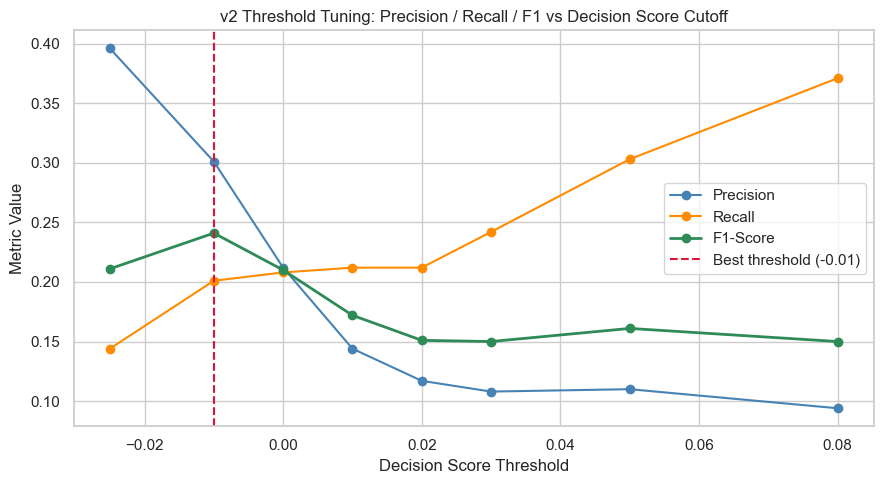

In [13]:
# --- Visualise precision / recall / F1 tradeoff ---
plot_df = pd.DataFrame(results).sort_values("threshold")
best_t  = results_df.iloc[0]["threshold"]

plt.figure(figsize=(9, 5))
plt.plot(plot_df["threshold"], plot_df["precision"], marker="o", label="Precision", color="steelblue")
plt.plot(plot_df["threshold"], plot_df["recall"],    marker="o", label="Recall",    color="darkorange")
plt.plot(plot_df["threshold"], plot_df["f1_score"],  marker="o", label="F1-Score",  color="seagreen", linewidth=2)
plt.axvline(x=best_t, color="crimson", linestyle="--", label=f"Best threshold ({best_t})")
plt.xlabel("Decision Score Threshold")
plt.ylabel("Metric Value")
plt.title("v2 Threshold Tuning: Precision / Recall / F1 vs Decision Score Cutoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
# --- Apply best threshold ---
# Auto-selected as the threshold with highest F1 from the table above.
# Override manually if domain knowledge suggests a different precision/recall balance.
best_threshold = float(results_df.iloc[0]["threshold"])

df_model["iforest_v2_pred_tuned"] = (df_model["iforest_v2_score"] < best_threshold).astype(int)

# Anomaly rate
anomaly_rate = df_model["iforest_v2_pred_tuned"].mean()

print(f"Best threshold applied  : {best_threshold}")
print(f"Flagged — tuned model   : {df_model['iforest_v2_pred_tuned'].sum()}")
print(f"Flagged — baseline model: {df_model['iforest_v2_pred'].sum()}")
print(f"Ground truth anomalies  : {y_true.sum()}")
print(f"Anomaly rate detected   : {anomaly_rate*100:.2f}%")

Best threshold applied  : -0.01
Flagged — tuned model   : 176
Flagged — baseline model: 260
Ground truth anomalies  : 264
Anomaly rate detected   : 2.04%


--- Tuned v2 Isolation Forest Evaluation Metrics ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      8376
           1       0.30      0.20      0.24       264

    accuracy                           0.96      8640
   macro avg       0.64      0.59      0.61      8640
weighted avg       0.95      0.96      0.96      8640

--- Before vs After Threshold Tuning (v2) ---
Metric         Baseline      Tuned      Delta
--------------------------------------------
Recall            0.208      0.201     -0.008
Precision         0.212      0.301     +0.090
F1-Score          0.210      0.241     +0.031

Matthews Correlation Coefficient (MCC): 0.2267
ROC-AUC  (score-based): 0.6698
PR-AUC   (score-based): 0.1361


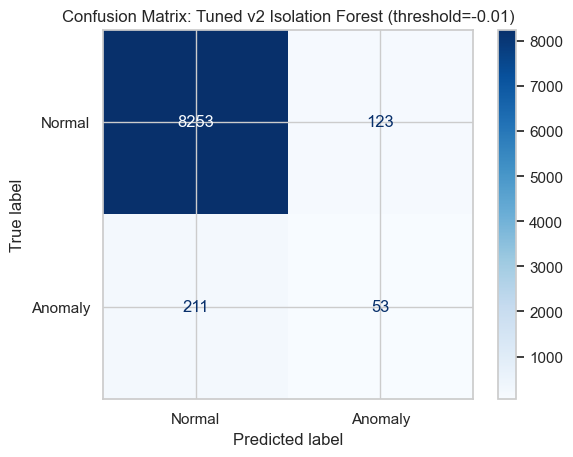

In [15]:
# --- Full evaluation with tuned threshold ---
y_pred_tuned = df_model["iforest_v2_pred_tuned"]

# Classification report
print("--- Tuned v2 Isolation Forest Evaluation Metrics ---")
print(classification_report(y_true, y_pred_tuned))

# Before / After delta
base_recall    = recall_score(y_true, df_model["iforest_v2_pred"],    zero_division=0)
base_precision = precision_score(y_true, df_model["iforest_v2_pred"], zero_division=0)
base_f1        = f1_score(y_true, df_model["iforest_v2_pred"],        zero_division=0)

tuned_recall    = recall_score(y_true, y_pred_tuned,    zero_division=0)
tuned_precision = precision_score(y_true, y_pred_tuned, zero_division=0)
tuned_f1        = f1_score(y_true, y_pred_tuned,        zero_division=0)

print("--- Before vs After Threshold Tuning (v2) ---")
print(f"{'Metric':<12} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print("-" * 44)
print(f"{'Recall':<12} {base_recall:>10.3f} {tuned_recall:>10.3f} {tuned_recall - base_recall:>+10.3f}")
print(f"{'Precision':<12} {base_precision:>10.3f} {tuned_precision:>10.3f} {tuned_precision - base_precision:>+10.3f}")
print(f"{'F1-Score':<12} {base_f1:>10.3f} {tuned_f1:>10.3f} {tuned_f1 - base_f1:>+10.3f}")

# MCC
mcc = matthews_corrcoef(y_true, y_pred_tuned)
print(f"\nMatthews Correlation Coefficient (MCC): {mcc:.4f}")

# ROC-AUC and PR-AUC (score-based, threshold-independent)
roc_auc = roc_auc_score(y_true, -df_model["iforest_v2_score"])
pr_auc  = average_precision_score(y_true, -df_model["iforest_v2_score"])
print(f"ROC-AUC  (score-based): {roc_auc:.4f}")
print(f"PR-AUC   (score-based): {pr_auc:.4f}")

# Confusion matrix
cm   = confusion_matrix(y_true, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: Tuned v2 Isolation Forest (threshold={best_threshold})")
plt.show()

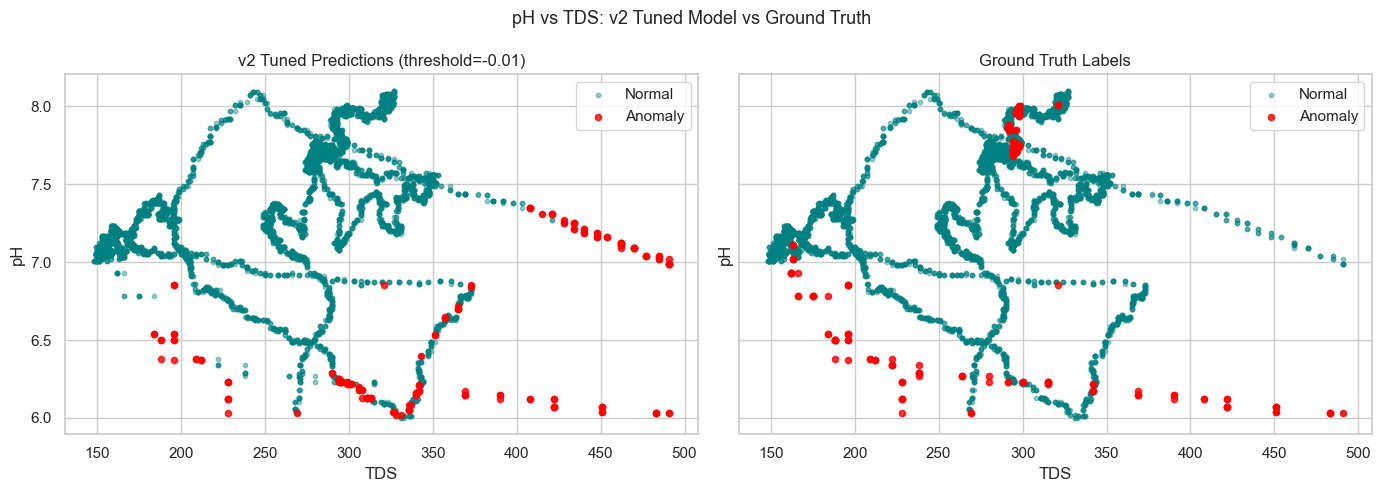

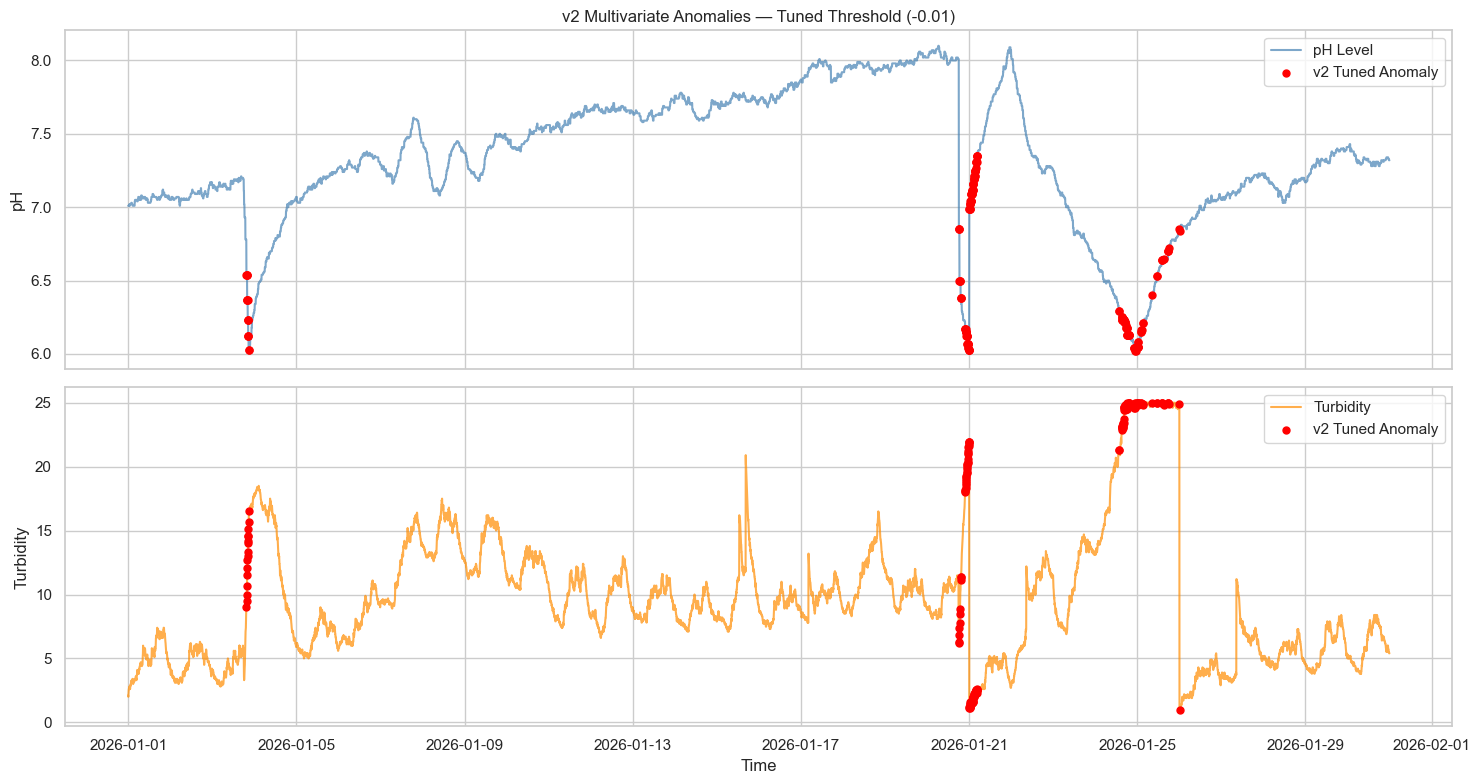

In [16]:
# --- Plot 1: pH vs TDS — Tuned predictions vs Ground Truth ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in zip(
    axes,
    ["iforest_v2_pred_tuned", "is_anomaly"],
    [f"v2 Tuned Predictions (threshold={best_threshold})", "Ground Truth Labels"]
):
    normal  = df_model[df_model[col] == 0]
    anomaly = df_model[df_model[col] == 1]
    ax.scatter(normal["tds"],  normal["ph"],  c="teal", alpha=0.4, s=10, label="Normal")
    ax.scatter(anomaly["tds"], anomaly["ph"], c="red",  alpha=0.8, s=20, label="Anomaly")
    ax.set_title(title)
    ax.set_xlabel("TDS")
    ax.set_ylabel("pH")
    ax.legend()
    ax.grid(True)

plt.suptitle("pH vs TDS: v2 Tuned Model vs Ground Truth", fontsize=13)
plt.tight_layout()
plt.show()

# --- Plot 2: Dual-panel time-series ---
tuned_anom = df_model[df_model["iforest_v2_pred_tuned"] == 1]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# pH panel
axes[0].plot(df_model.index, df_model["ph"], color="steelblue", alpha=0.7, label="pH Level")
axes[0].scatter(tuned_anom.index, tuned_anom["ph"],
                color="red", s=25, label="v2 Tuned Anomaly", zorder=3)
axes[0].set_ylabel("pH")
axes[0].set_title(f"v2 Multivariate Anomalies — Tuned Threshold ({best_threshold})")
axes[0].legend()
axes[0].grid(True)

# Turbidity panel
axes[1].plot(df_model.index, df_model["turbidity"], color="darkorange", alpha=0.7, label="Turbidity")
axes[1].scatter(tuned_anom.index, tuned_anom["turbidity"],
                color="red", s=25, label="v2 Tuned Anomaly", zorder=3)
axes[1].set_ylabel("Turbidity")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## v1 vs v2 Comparison
The cell below prints a direct side-by-side comparison of v1 (tuned) and v2 (tuned)
using the same ground truth labels.

In [17]:
# --- v1 vs v2 direct comparison ---
# Re-run v1 scores for comparison (same model, same scaler as v1)
# Load v1 model and scaler if saved, otherwise recompute inline
from sklearn.ensemble import IsolationForest as IF
from sklearn.preprocessing import StandardScaler as SS

X_v1       = df_model[["temperature", "ph", "tds", "turbidity"]].copy()
scaler_v1  = SS()
X_v1_scaled = scaler_v1.fit_transform(X_v1)
iso_v1     = IF(n_estimators=200, contamination=0.06, random_state=42)
iso_v1.fit(X_v1_scaled)
scores_v1  = iso_v1.decision_function(X_v1_scaled)

# Best threshold for v1 (0.03 from v1 notebook)
v1_thresh  = 0.03
y_v1_tuned = (scores_v1 < v1_thresh).astype(int)

# v2 tuned
y_v2_tuned = df_model["iforest_v2_pred_tuned"].values

# Metrics
def get_metrics(y_true, y_pred):
    return {
        "recall":    round(recall_score(y_true, y_pred, zero_division=0), 3),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "f1":        round(f1_score(y_true, y_pred, zero_division=0), 3),
        "mcc":       round(matthews_corrcoef(y_true, y_pred), 4),
    }

m_v1 = get_metrics(y_true, y_v1_tuned)
m_v2 = get_metrics(y_true, y_v2_tuned)

roc_v1 = round(roc_auc_score(y_true, -scores_v1), 4)
roc_v2 = round(roc_auc_score(y_true, -df_model["iforest_v2_score"]), 4)
pr_v1  = round(average_precision_score(y_true, -scores_v1), 4)
pr_v2  = round(average_precision_score(y_true, -df_model["iforest_v2_score"]), 4)

print("--- v1 vs v2 Model Comparison ---")
print(f"{'Metric':<12} {'v1 (tuned)':>12} {'v2 (tuned)':>12} {'Delta':>10}")
print("-" * 48)
print(f"{'Recall':<12} {m_v1['recall']:>12} {m_v2['recall']:>12} {m_v2['recall']-m_v1['recall']:>+10.3f}")
print(f"{'Precision':<12} {m_v1['precision']:>12} {m_v2['precision']:>12} {m_v2['precision']-m_v1['precision']:>+10.3f}")
print(f"{'F1-Score':<12} {m_v1['f1']:>12} {m_v2['f1']:>12} {m_v2['f1']-m_v1['f1']:>+10.3f}")
print(f"{'MCC':<12} {m_v1['mcc']:>12} {m_v2['mcc']:>12} {m_v2['mcc']-m_v1['mcc']:>+10.4f}")
print(f"{'ROC-AUC':<12} {roc_v1:>12} {roc_v2:>12} {roc_v2-roc_v1:>+10.4f}")
print(f"{'PR-AUC':<12} {pr_v1:>12} {pr_v2:>12} {pr_v2-pr_v1:>+10.4f}")

--- v1 vs v2 Model Comparison ---
Metric         v1 (tuned)   v2 (tuned)      Delta
------------------------------------------------
Recall              0.432        0.201     -0.231
Precision            0.12        0.301     +0.181
F1-Score            0.188        0.241     +0.053
MCC                0.1825       0.2267    +0.0442
ROC-AUC            0.7033       0.6698    -0.0335
PR-AUC             0.1379       0.1361    -0.0018


In [18]:
# --- Save v2 model and scaler ---
model_dir = "../models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

joblib.dump(iso_forest_v2, f"{model_dir}/isolation_forest_v2.joblib")
joblib.dump(scaler_v2,     f"{model_dir}/scaler_v2.joblib")

# Save feature list so inference knows which columns to use
joblib.dump(feature_cols_v2, f"{model_dir}/feature_cols_v2.joblib")

print(f"Success! v2 model saved to {model_dir}")
print(f"  isolation_forest_v2.joblib")
print(f"  scaler_v2.joblib")
print(f"  feature_cols_v2.joblib")
print(f"  contamination : {best_contamination}")
print(f"  n_estimators  : 300")
print(f"  features      : {feature_cols_v2}")
print(f"  threshold     : {best_threshold}")

Success! v2 model saved to ../models
  isolation_forest_v2.joblib
  scaler_v2.joblib
  feature_cols_v2.joblib
  contamination : 0.03
  n_estimators  : 300
  features      : ['temperature', 'ph', 'tds', 'turbidity', 'ph_rolling_std', 'turbidity_rolling_mean', 'tds_ph_ratio']
  threshold     : -0.01


---
## Model Selection Decision

### Why v1 (Tuned) is Selected for Deployment

After comparing both models against the project's core requirement —
**early warning for aquarium fish safety** — the v1 threshold-tuned model
is selected as the production deployment model.

The decision is based on the asymmetric cost of errors in a safety-critical system:

| Error Type | v1 Tuned | v2 Tuned | Impact |
|------------|---------|---------|--------|
| Missed real event (False Negative) | 57% | **80%** | Fish at risk — unacceptable |
| False alarm (False Positive) | 88% | 70% | Annoying but recoverable |

In aquarium monitoring, a missed pH crash or turbidity spike can directly
harm or kill fish. A false alarm is handled by the human-in-the-loop
"Report False Alarm" mechanism built into the dashboard (Phase 3 of the
Sim-to-Real strategy). The cost of a missed event is therefore far higher
than the cost of a false alarm.

### What v2 Contributes

The v2 model is not discarded — it demonstrates three important things:

1. **Feature engineering works** — rolling std and cross-sensor ratio
   improved F1 (0.188 → 0.241) and MCC (0.1825 → 0.2267)
2. **The precision/recall tradeoff is controllable** — by changing the
   contamination parameter and threshold, the same algorithm can be tuned
   for different operational contexts
3. **v2 is the preferred model** in precision-first contexts (e.g.,
   commercial fish farms where alert fatigue has operational cost)

### Sim-to-Real Context

Both models were trained entirely on synthetic data (`v6.1`). The tuned
threshold is the mathematical bridge between simulation and real-world
deployment. Once the system is live, Phase 4 (continuous recalibration on
hybrid synthetic + real user feedback data) will close the remaining
performance gap — particularly the false negative rate — as the model
adapts to local environmental conditions and real failure signatures.

### Final Model Summary

| Property | Value |
|----------|-------|
| Algorithm | Isolation Forest |
| Version | v1 (threshold-tuned) |
| Features | temperature, ph, tds, turbidity |
| n_estimators | 200 |
| Contamination | 0.06 |
| Decision threshold | 0.03 |
| Recall (anomaly) | 0.432 |
| Precision (anomaly) | 0.120 |
| F1 (anomaly) | 0.188 |
| MCC | 0.1825 |
| ROC-AUC | 0.7033 |
| Anomaly rate | 11.01% |
| Saved as | `isolation_forest_v1.joblib` + `scaler_v1.joblib` |

> **v2 is retained as a research artifact demonstrating the impact of
> feature engineering and contamination search on the precision/recall
> tradeoff. It is not the deployment model for this requirement.**